In [ ]:
import pandas as pd
housing= pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
def find_correlation(housing_numeric):
  # computing standard correlation coefficient
  corr_matrix = housing_numeric.corr()
  # fetch and return attribute correlates
  # with the median housing value
  return corr_matrix["median_house_value"].sort_values(
    ascending=False)

# drop ocean_proximity column
housing_numeric = housing.drop("ocean_proximity", axis=1)
# find correlation coefficient
cor_coef = find_correlation(housing_numeric)
print("Correlation Coefficient::", cor_coef)

Correlation Coefficient:: median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


<Axes: xlabel='median_income', ylabel='median_house_value'>

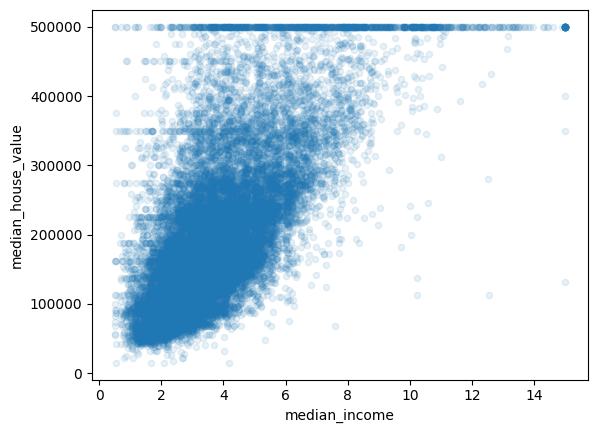

In [ ]:
# scatter plot diagram
housing.plot(kind='scatter',
             x="median_income", y="median_house_value",
             alpha=0.1)

array([[<Axes: title={'center': 'median_income'}>]], dtype=object)

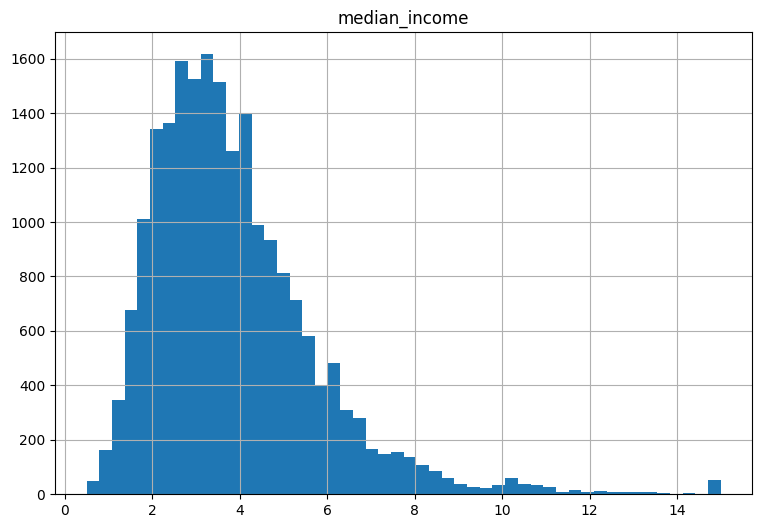

In [ ]:
housing.hist(column='median_income',
             bins=50, figsize=(9,6))

<Axes: >

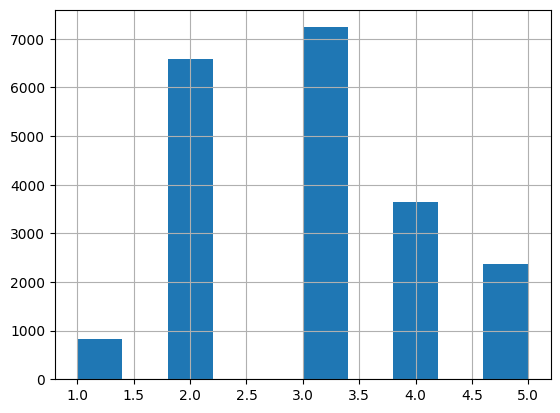

In [ ]:
import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                              labels=[1, 2, 3, 4, 5])

housing["income_cat"].hist()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error

def fetch_housing_data():
  return pd.read_csv(
    "https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")

def set_income_category(housing_selected):
    # set income category based on median income
    housing_selected["income_cat"] = pd.cut(housing_selected["median_income"],
                                            bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                            labels=[1, 2, 3, 4, 5])
    return housing_selected

def get_strat_train_test_dataset(housing_selected):
    # stratified sampling
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    housing_split = split.split(housing_selected, housing_selected["income_cat"])
    # get train and test dataset
    for train_index, test_index in housing_split:
        train_set = housing_selected.loc[train_index]
        test_set = housing_selected.loc[test_index]

    # drop income_category from train and test dataset
    for set_ in (train_set, test_set):
        set_.drop("income_cat", axis=1, inplace=True)

    return train_set, test_set

def sprt_train_and_label_set(train_set):
    # drop median_house_value from training data
    housing_tr = train_set.drop("median_house_value", axis=1)
    # create a new dataframe with median_house_value
    housing_labels = train_set["median_house_value"].copy()
    return housing_tr, housing_labels

def get_rmse(housing_labels, predicted_data):
    # get mean squared error to analyse prediction error
    mse = mean_squared_error(housing_labels, predicted_data)
    rmse = np.sqrt(mse)
    return rmse

# get housing data
housing = fetch_housing_data()
# copy median_income and median_house_value
housing_selected = housing[['median_income', 'median_house_value']].copy()
# set income category based on median_icome
housing_selected = set_income_category(housing_selected)
# stratified sampling
train_set, test_set = get_strat_train_test_dataset(housing_selected)
# seperate label and data from training set
housing_tr, housing_labels = sprt_train_and_label_set(train_set)

In [ ]:
from sklearn.linear_model import LinearRegression
# linear regression model for best fit
lin_reg = LinearRegression()
lin_reg.fit(housing_tr, housing_labels)

# sample data to test from training set
sample_data = housing_tr.iloc[:5]
sample_labels = housing_labels.iloc[:5]

# predict the median_house_value
predicted_data = lin_reg.predict(sample_data)
print("Predicted Price:", predicted_data)
print("Actual Price:", list(sample_labels))

Predicted Price: [135958.75805364 309735.008975   165232.3998617  138162.41971241
 232903.1766333 ]
Actual Price: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [ ]:
# pass the training data and identify the prediction error
predicted_data = lin_reg.predict(housing_tr)
lin_rmse = get_rmse(housing_labels, predicted_data)
print("root mean square error:", lin_rmse)

root mean square error: 84056.18763327331


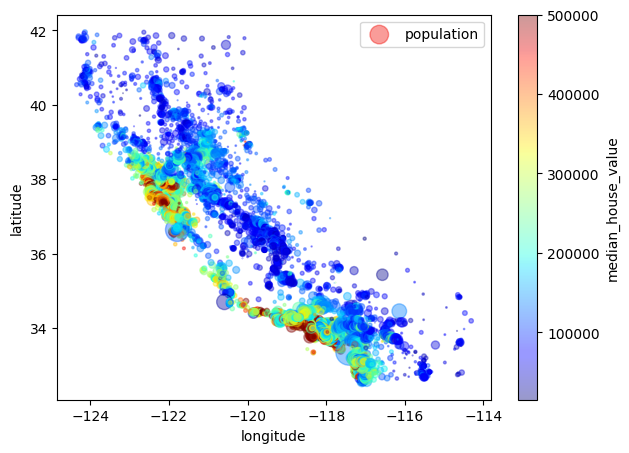

In [ ]:
import matplotlib.pyplot as plt
# plot
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(7,5),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,)
plt.legend()

In [ ]:
from sklearn.impute import SimpleImputer

# drop ocean_proximity column
housing_num = housing.drop("ocean_proximity", axis=1)

# imputer instance
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)
housing_imputer = imputer.transform(housing_num)
print("Imputer return data type:", type(housing_imputer))

# convert back to pandas dataframe
housing_new = pd.DataFrame(
    housing_imputer, columns=housing_num.columns, index=housing_num.index)
print("New Housing Dataset:")
print(housing_new.info())

Imputer return data type: <class 'numpy.ndarray'>
New Housing Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


def transformation_pipeline():
    # pipeline execution
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('std_scaler', StandardScaler())
    ])
    return num_pipeline


# get housing data
housing = fetch_housing_data()
# set income category based on median_icome
housing = set_income_category(housing)
# stratified sampling
train_set, test_set = get_strat_train_test_dataset(housing)
# seperate label and data from training set
housing_tr, housing_labels = sprt_train_and_label_set(train_set)
# drop ocean_proximity
housing_num = housing_tr.drop("ocean_proximity", axis=1)
# numeric pipeline execution
num_pipeline = transformation_pipeline()
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [ ]:
from sklearn.linear_model import LinearRegression

# linear regression model to identify best fit
lin_reg = LinearRegression()
lin_reg.fit(housing_num_tr, housing_labels)
# pass the prepared data and predict the housing price
predicted_data = lin_reg.predict(housing_num_tr)
# pass the predicted data and identify the prediction error
lin_rmse = get_rmse(housing_labels, predicted_data)
print("Linear Regression Prediction error:", lin_rmse)

Linear Regression Prediction error: 69957.72079714121


In [ ]:
housing[["ocean_proximity"]].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# fetch ocean_proximity
housing_cat = housing[["ocean_proximity"]]
# one hot encoder
cat_encoder = OneHotEncoder()
housing_cat_encoder = cat_encoder.fit_transform(housing_cat)
# convert sparse matrix to array to dispaly the result
result = housing_cat_encoder.toarray()
print("Data:")
print(result)
category_list = cat_encoder.categories_
print("Category List::", category_list)

Data:
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Category List:: [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing_tr)

In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


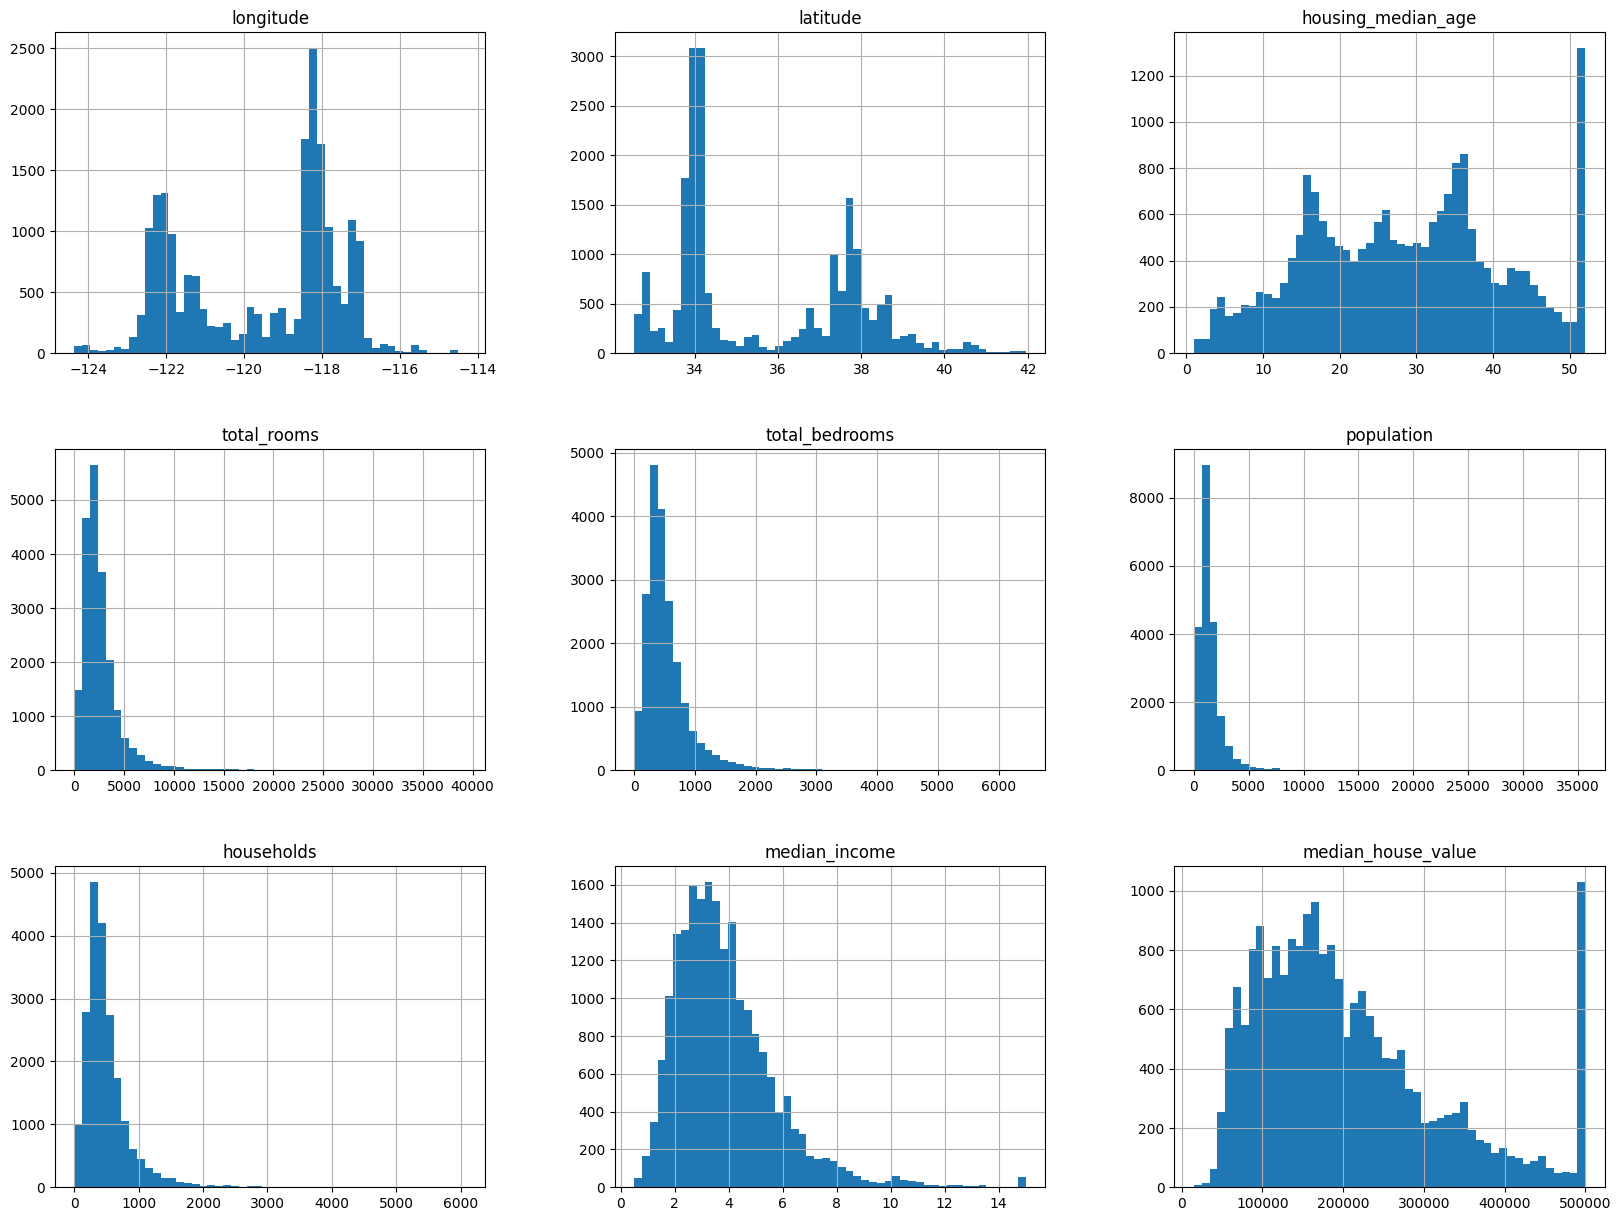

In [ ]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))
plt.show()

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix,households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self
  def transform(self, X, y=None):
    rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
    population_per_household = X[:, population_ix] / X[:, households_ix]
    bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
    return np.c_[X, rooms_per_household, population_per_household,
                 bedrooms_per_room]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


def transformation_pipeline():
    # pipeline execution
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler())
    ])
    return num_pipeline

def complete_pipeline(num_pipeline, num_attribs, cat_attribs):
    full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),])
    return full_pipeline


# numeric pipeline execution
num_pipeline = transformation_pipeline()
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]
# pipeline execution of numeric and column attribute
full_pipeline = complete_pipeline(num_pipeline, num_attribs, cat_attribs)
housing_prepared = full_pipeline.fit_transform(housing_tr)

In [ ]:
# linear regression model to identify best fit
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)
# pass the prepared data and predict the housing price
predicted_data = lin_reg.predict(housing_prepared)
# pass the predicted data and identify the prediction error
lin_rmse = get_rmse(housing_labels, predicted_data)
print("Linear Regression Prediction error:", lin_rmse)

Linear Regression Prediction error: 68627.87390018745


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Decision tree regressor
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)
# predict the price
predicted_data = tree_reg.predict(housing_prepared)
# pass the predicted data and identify the prediction error
tree_rmse = get_rmse(predicted_data, housing_labels)
print("Decision tree prediction error", tree_rmse)

Decision tree prediction error 0.0


In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Random Forest Regressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)
# predict the price
predicted_data = forest_reg.predict(housing_prepared)
# identify the prediction error
rf_rmse = get_rmse(housing_labels, predicted_data)
print("Random forest prediction error", rf_rmse)

Random forest prediction error 18713.54299470048


In [ ]:
from sklearn.model_selection import cross_val_score

def cross_validation(reg_model, housing_prepared, housing_labels):
    scores = cross_val_score(
      reg_model, housing_prepared,
      housing_labels,
      scoring="neg_mean_squared_error", cv=10)
    rmse_scores = np.sqrt(-scores)
    print("Scores:", rmse_scores)
    print("Mean:", rmse_scores.mean())
    print("StandardDeviation:", rmse_scores.std())

print("Decision Tree Regression Model Cross Validation")
cross_validation(tree_reg, housing_prepared, housing_labels)
print("Linear Regression Model Cross Validation")
cross_validation(lin_reg, housing_prepared, housing_labels)
print("Random Forest Regression Model Cross Validation")
cross_validation(forest_reg, housing_prepared, housing_labels)

Decision Tree Regression Model Cross Validation
Scores: [72286.28877816 72306.4799409  68315.83128591 72472.44913087
 68682.00749658 77834.16347865 71405.60788793 73939.40385505
 69872.43649934 70946.9663717 ]
Mean: 71806.16347250923
StandardDeviation: 2615.205648430742
Linear Regression Model Cross Validation
Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
StandardDeviation: 2880.3282098180694
Random Forest Regression Model Cross Validation
Scores: [51308.16938988 48691.64737423 46989.90186808 51736.9304817
 47489.48092516 52311.59357644 52265.73851964 50024.30451874
 48692.64834466 53560.66921352]
Mean: 50307.10842120493
StandardDeviation: 2138.350355295492


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# set combination of parameter values
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features':[2, 4, 6, 8]},
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features':[2, 3, 4]},
]
# Random Forest Regressor model
forest_reg = RandomForestRegressor()

# GridSearchCV for best combination
grid_search = GridSearchCV(
    forest_reg, param_grid, cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

# check evaluation score for each combination
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

KeyboardInterrupt: 

In [ ]:
# best estimator
print(grid_search.best_estimator_)

In [ ]:
final_model = grid_search.best_estimator_

housing_test = test_set.drop("median_house_value", axis=1)
housing_lbl_test = test_set["median_house_value"].copy()

housing_test_prepared = full_pipeline.transform(housing_test)

final_predictions = final_model.predict(housing_test_prepared)

final_rmse = get_rmse(final_predictions, housing_lbl_test)
print("Test set prediction error:", final_rmse)